# 01 - Patient-Level Data Engineering

This notebook reproduces the data preprocessing pipeline and generates the patient-level dataset used throughout the study. It includes data cleaning, study cohort definition, temporal window construction, and feature engineering steps required for all subsequent analyses.


**Objectives:**
- Extract patient information from the Tarragona databases.
- Create anonymized patient identifiers.
- Clean and consolidate duplicated records.
- Handle missing values.
- Define temporal observation windows.
- Perform feature engineering.
- Generate descriptive statistics.
- Export the final patient-level dataset.

## Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from utils import extract_data

In [2]:
# dblinks from Tarragona
dblinks = ['@P6211_exp']

## 1. Data extraction

In [3]:
q_usuaris = """
    SELECT 
        u.usua_cip AS cip_actual,
        c.cip_cip_anterior AS cip_anterior,
        c.cip_digit_anterior,
        TO_DATE(u.usua_data_naixement, 'J') AS data_naix,
        u.usua_sexe AS sexe,
        u.usua_situacio AS situacio,                                -- A = actiu, T= Trasllat, D = defunció
        TO_DATE(u.usua_data_situacio,'J') AS data_situacio,
        u.usua_data_defuncio AS data_defuncio,
        u.usua_cronic,
    
        CASE 
            WHEN p.up_cod_pg_sp = 'A0018' THEN 'MACA'
            WHEN p.up_cod_pg_sp = 'A0017' THEN 'PCC'
            ELSE NULL
        END AS cronic,

        p.up_data_ini AS data_cronic,
--        g.gma_cod,
        g.gma_plng,
        g.gma_pniv
--        g.gma_etiqueta

    FROM usutb040{dbl} u
    
    JOIN usutb011{dbl} c
        ON c.cip_usuari_cip = u.usua_cip

    LEFT JOIN prstb014{dbl} p
        ON c.cip_cip_anterior = p.up_cod_u  
        AND p.up_cod_pg_sp IN ('A0018', 'A0017')                    -- només seleccionem els que tenen MACA i PCC, hi ha molts altres codis

    LEFT JOIN gmatb002{dbl} g
        ON c.cip_cip_anterior = g.gma_cip

    WHERE usua_uab_ep = '0208'                                      -- entitat proveïdora ICS
    AND usua_uab_sap IN ('05')                                      -- SAP: Serveri d'Atenció Primària Tarragona (05), Reus (06)
    -- AND cip_usuari_cip = usua_cip
    AND TO_DATE(usua_data_naixement, 'J') <= TO_DATE('1952/12/31', 'YYYY/MM/DD')
 """

In [4]:
df_usuaris = extract_data(q_usuaris, dblinks)
print(f'Number of users: {df_usuaris.shape[0]}')

Number of users: 113242


Create a column with *cip_anterior_14*:

In [5]:
new_column = df_usuaris['cip_anterior'] + df_usuaris['cip_digit_anterior']  # Define the values of the new column
df_usuaris.insert(loc=2, column='cip_anterior_14', value=new_column)        # Insert the column at the desired position
df_usuaris = df_usuaris.drop(columns='cip_digit_anterior')                  # Drop the useless columns

Create ids for the pseudonymized identificative fields: *cip_actual*, *cip_anterior*

In [6]:
# Random generator
rng = np.random.default_rng(42)

# Combine both columns to get all unique cips
all_cips = pd.concat([
    df_usuaris['cip_actual'],
    df_usuaris['cip_anterior']
]).dropna().unique()

# Create random IDs
ids = rng.permutation(np.arange(1, len(all_cips) + 1))
mapping = dict(zip(all_cips, ids))

# Apply mapping to both columns
df_usuaris['id_cip_actual'] = df_usuaris['cip_actual'].map(mapping)
df_usuaris['id_cip_anterior'] = df_usuaris['cip_anterior'].map(mapping)

df_usuaris.insert(0, 'id_cip_actual', df_usuaris.pop('id_cip_actual'))
df_usuaris.insert(1, 'id_cip_anterior', df_usuaris.pop('id_cip_anterior'))

df_usuaris = df_usuaris.sort_values('id_cip_anterior').reset_index(drop=True)

print(f'Number of rows: {df_usuaris.shape[0]}')

Number of rows: 113242


## 2. Patient Identifier Harmonization
A patient can have a temporary CIP until the permanent one is not defined, so we can have diagnostics, treatments and lab tests related to the temporary ones. For these reason, table that relates the values of the CIP actual of the patients and the temporary ones must be created. One patient can have more than one temporary CIP, and before generating the table with the cip relations, duplicates and incongruencies need to be checked.

### 2.1 Data Cleaning - *id_cip_actual* and *id_cip_anterior*

1. Check if each *id_cip_anterior* corresponds only to a single and unique *id_cip_actual*.
2. If a *id_cip_anterior* correlates with more than one *id_cip_actual*, remove those records.

In [7]:
# Count how many different values of cip_actual there are for each cip_anterior - select the ones than have more than 1
mask_cips = df_usuaris.groupby('id_cip_anterior')['id_cip_actual'].nunique() > 1
print(f'Number of cip_anterior values that correspond to more than one cip_actual: {mask_cips.sum()}')

# Remove the selected records
df_usuaris = df_usuaris[~df_usuaris['id_cip_anterior'].isin(mask_cips[mask_cips].index)].reset_index(drop=True)
print(f'Number of rows: {df_usuaris.shape[0]}')

Number of cip_anterior values that correspond to more than one cip_actual: 0
Number of rows: 113242


### 2.2 Relation cip table

In [8]:
# Select the interesting columns: cip_anterior and cip_actual
cip_relations = df_usuaris[['cip_anterior', 'cip_anterior_14', 'cip_actual', 'id_cip_anterior', 'id_cip_actual']]

# Remove the repeated relations
cip_relations = cip_relations.drop_duplicates(keep='first')

print(f'Number of rows in cip_relations: {cip_relations.shape[0]}')

Number of rows in cip_relations: 113242


In [9]:
print(f'Duplicates of cip_anterior in cip_relations: {cip_relations.cip_anterior.duplicated().sum()}')
print(f'Duplicates of cip_anterior_14 in cip_relations: {cip_relations.cip_anterior_14.duplicated().sum()}')
print(f'Duplicates of cip_actual in cip_relations: {cip_relations.cip_actual.duplicated().sum()}')

Duplicates of cip_anterior in cip_relations: 0
Duplicates of cip_anterior_14 in cip_relations: 0
Duplicates of cip_actual in cip_relations: 16917


### 2.3 Drop all *id_cip_anterior* that doesn't exist in *id_cip_actual*
When getting diagnoses, treatments, lab tests and derivations *id_cip_anterior* will be used for merging, so all possible cip values need to be in *id_cip_anterior* column. For each *id_cip_actual* there must be a row where *id_cip_actual == cip_anterior*, all rows where this is not accomplished will be discarded.

In [10]:
# All distinct values of cip_actual
usua_actual = pd.Series(cip_relations['id_cip_actual'].unique())

# Mask all rows where cip_actual == cip_anterior
mask_cips_2 = (cip_relations['id_cip_anterior'] == cip_relations['id_cip_actual'])

# Get all rows where the mask is accomplished
valid = cip_relations.loc[mask_cips_2, 'id_cip_actual']

# Discard all cip_actual that doesn't have a correspondence cip_anterior = cip_actual from cip_relations and df_usuaris
to_discard = usua_actual[~usua_actual.isin(valid)]
cip_relations = cip_relations[~cip_relations['id_cip_actual'].isin(to_discard)]
df_usuaris = df_usuaris[~df_usuaris['id_cip_actual'].isin(to_discard)]
print(f'Number of cip_anterior: {cip_relations.shape[0]}')
print(f'Number of users: {df_usuaris.shape[0]}')

Number of cip_anterior: 113242
Number of users: 113242


In [11]:
df_usuaris.drop(columns=(['cip_actual', 'cip_anterior', 'cip_anterior_14']), inplace=True)

## 3. Study Cohort Definition

### 3.1 Correct inconsistent death records
Change *situacio* from 'A' to 'D' for those patients who are Active but have an entry in *data_defuncio*:

In [12]:
died_but_active = ((df_usuaris['situacio'] != 'D') & (df_usuaris['data_defuncio'].notna()))
df_usuaris.loc[died_but_active, 'situacio'] = 'D'

### 3.2 Handle missing death dates

Theoretically, there would be a value in *data_defuncio* for all patients that are dead (*situacio* = 'D'), but this is not always true. :
- For all the duplicated records where in some entries *data_defuncio* is empty and in others is not, fill the missing values with the available values in non-empty entries.
- For all the records that are dead but do not have any value in *data_defuncio*, *data_situacio* is considered as it.

In [13]:
# Number of dead patients
n_users_dead = (df_usuaris['situacio'] == 'D').sum()
print(f'Dead patients: {n_users_dead}')

# Number of dead patients wihtout data_defuncio
no_data_def = (
    (df_usuaris['situacio'] == 'D') &
    (df_usuaris['data_defuncio'].isna())
    ).sum()

print(f'Dead patients with empty data_defuncio: {no_data_def}')
print(f'In percentage: {round(no_data_def*100/n_users_dead, 2)} %')

Dead patients: 43121
Dead patients with empty data_defuncio: 36377
In percentage: 84.36 %


In [14]:
# Dead patients 
dead_mask = df_usuaris['situacio'] == 'D'

# How many different values in data_defuncio we have for each patient
missing_dates = df_usuaris.loc[dead_mask].groupby('id_cip_actual')['data_defuncio'].agg(['size', 'count'])   # size = total rows, count = non-null values
missing_dates.head()

,size,count
id_cip_actual,,
4,1,0
6,1,0
8,1,0
11,2,0
19,2,0


In [15]:
# Get patients with different values in data_defuncio in its duplicates: at least one value exists & at least one value is missing
mixed_values = missing_dates[(missing_dates['count'] > 0) & (missing_dates['count'] < missing_dates['size'])]
mask_mixed_values = dead_mask & df_usuaris['id_cip_actual'].isin(mixed_values.index)

# For those users that have some rows with usua_data_defuncio and some rows with NaN, get the max date and impute it on the missing ones
df_usuaris.loc[mask_mixed_values, 'data_defuncio'] = (
    df_usuaris.loc[mask_mixed_values]
    .groupby('id_cip_actual')['data_defuncio']
    .transform('max')
)

# Assign data_situacio as data_defuncio if data_defuncio is still missing
no_data_def_2 = (
    (df_usuaris['situacio'] == 'D') &
    (df_usuaris['data_defuncio'].isna())
    )

df_usuaris.loc[no_data_def_2, 'data_defuncio'] = df_usuaris.loc[no_data_def_2, 'data_situacio']

no_data_def_3 = (
    (df_usuaris['situacio'] == 'D') &
    (df_usuaris['data_defuncio'].isna())
    )

print(f'Dead patients with empty data_defuncio after handling missing values: {no_data_def_3.sum()}')

Dead patients with empty data_defuncio after handling missing values: 0


### 3.3 Exclude patients deceased before 01/01/2024
As a 12-month mortality model will be developed, all patients that have died before passing one year since 01/01/2023 must be excluded, meaning all patients that have died before 01/01/2024 are excluded.

In [16]:
died_before = (
    (df_usuaris['situacio'] == 'D') &
    (df_usuaris['data_defuncio'].dt.year < 2024)
    )

df_usuaris = df_usuaris[~died_before]
print(f'Number of rows removing the users that died before 01/01/2024: {df_usuaris.shape[0]}')

Number of rows removing the users that died before 01/01/2024: 74127


### 3.4 Restrict the study period

As the cohort involves data of 3 years (2023-2025),  the situations, cronic labels  and deaths validated after 31/12/2025 are excluded.

In [17]:
df_usuaris['data_cronic'] = pd.to_datetime(df_usuaris['data_cronic'])

valor_after = (
    (df_usuaris['data_situacio'].dt.year > 2025) | 
    (df_usuaris['data_defuncio'].dt.year > 2025) |
    (df_usuaris['data_cronic'].dt.year > 2025)
    )

df_usuaris = df_usuaris[~valor_after]
print(f'Number of rows removing valorations after 31/12/2025: {df_usuaris.shape[0]}')

Number of rows removing valorations after 31/12/2025: 72151


## 4. Data Cleaning

### 4.1 Resolve duplicated patient records
From the SQL extraccion there is often more than one row per patient, so duplicate records should be handled to obtain a patient-level dataset (one row per patient).

In [18]:
# Duplicates of cip_actual
total_dupliates_actual = df_usuaris.id_cip_actual.duplicated().sum()
print(f'Number of duplicates of id_cip_actual: {total_dupliates_actual}')

Number of duplicates of id_cip_actual: 10576


Count the number of nulls there are per row so when dropping duplicates on *cip_actual*, keep the rows with less missing values:

In [19]:
# Create a new column counting the missing values per row
df_usuaris.loc[:, "n_nulls"] = df_usuaris.isnull().sum(axis=1)

Explore which variables values of the same record (id_cip_actual) differ in different entries (id_cip_actual duplicates) in order to understand which data is needed to ne handled:

In [20]:
# keep=False mantains all the duplicated rows to compare the values between them
duplicates_actual = df_usuaris[df_usuaris['id_cip_actual'].duplicated(keep=False)]

# Which variables have diferent values for duplicated cip_actual
dif_occurrences_actual = (duplicates_actual
                          .drop(columns=['n_nulls'])    # we will not consider this columns when handling duplicates
                          .groupby('id_cip_actual')
                          .nunique(dropna=True))        # nunique counts the different entries for each variables for the groups of cip_actual

# For cronic columns, NaN, PCC, MACA as different values
cols_nan_distinct = ['cronic', 'usua_cronic', 'data_cronic']
dif_occurrences_actual[cols_nan_distinct] = (
    duplicates_actual.groupby('id_cip_actual')[cols_nan_distinct].nunique(dropna=True)  
)

dif_cols = dif_occurrences_actual.columns[(dif_occurrences_actual > 1).any()]               # which columns (variables) have different values for each record entry

print(f'Variables of the same record whose values differ in different entries:\n {dif_cols}')

Variables of the same record whose values differ in different entries:
 Index(['id_cip_anterior', 'gma_plng'], dtype='str')


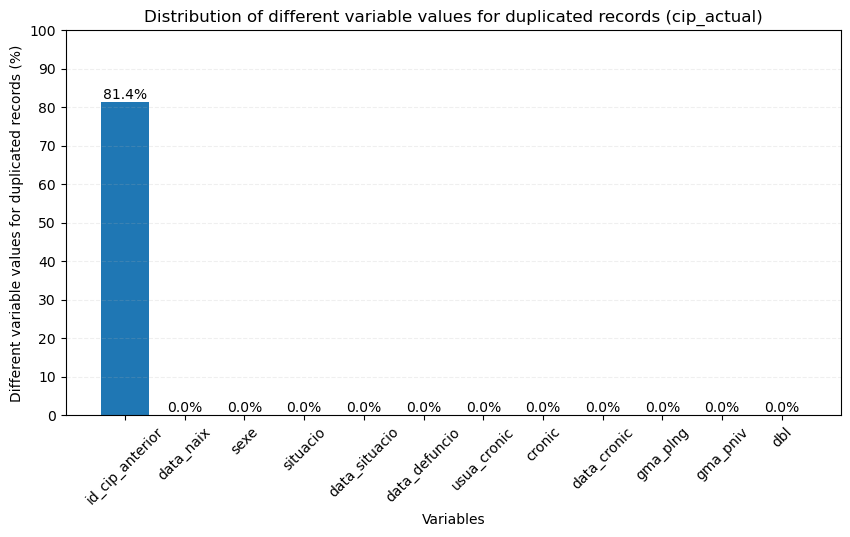

In [21]:
# 2 = different value of that column in 2 entries of the same cip_anterior - create a mask (comes from the nunique())
dif_counts_actual = (dif_occurrences_actual > 1).sum()
percentages = dif_counts_actual / total_dupliates_actual * 100

plt.figure(figsize=(10,5))
bars = plt.bar(dif_occurrences_actual.columns, percentages)
plt.bar_label(bars, fmt='%.1f%%')
plt.xlabel('Variables')
plt.ylabel('Different variable values for duplicated records (%)')
plt.xticks(rotation=45)
plt.yticks(range(0,101,10))
plt.grid(alpha=0.2, linestyle='--', axis='y')
plt.title('Distribution of different variable values for duplicated records (cip_actual)')
plt.show()

In [22]:
dif_occurrences_actual['cols_dif_values'] = dif_occurrences_actual.apply(lambda row: ','.join(row.index[row > 1]), axis=1)
dif_occurrences_actual.head()

,id_cip_anterior,data_naix,sexe,situacio,data_situacio,data_defuncio,usua_cronic,cronic,data_cronic,gma_plng,gma_pniv,dbl,cols_dif_values
id_cip_actual,,,,,,,,,,,,,
7,2,1,1,1,1,0,0,0,0,1,1,1,id_cip_anterior
9,2,1,1,1,1,0,0,0,0,1,1,1,id_cip_anterior
13,2,1,1,1,1,0,0,0,0,0,0,1,id_cip_anterior
15,2,1,1,1,1,0,0,0,0,0,0,1,id_cip_anterior
43,2,1,1,1,1,0,0,0,0,0,0,1,id_cip_anterior


In [23]:
dif_occurrences_actual['cols_dif_values'].value_counts()

cols_dif_values
id_cip_anterior             8607
id_cip_anterior,gma_plng       1
Name: count, dtype: int64

It can be observed that the only value that differs between *id_cip_actual* duplicates is *id_cip_anterior*, so all duplicated rows are removed as they are not providing any additional information.  
The dropping criteria is keeping the duplicated rows that present less null values.

In [24]:
# Get all cip_atual records that have duplicates and different values on those variables
dup_cip_anterior = pd.Series(dif_occurrences_actual[dif_occurrences_actual['cols_dif_values'] == 'id_cip_anterior'].index)

# Create a mask in df_usuaris
mask = df_usuaris['id_cip_actual'].isin(dup_cip_anterior)

# Mantain the records without duplicates and drop the duplicates that have higher n_nulls
df_usuaris = pd.concat([
    df_usuaris[~mask],
    (df_usuaris[mask]
    .sort_values('n_nulls', ascending=True)             # sort by ascending n_nulls
    .drop_duplicates('id_cip_actual', keep='first'))    # keep the row with less nulls
    ]).sort_index()

print(f'Number of users: {df_usuaris.shape[0]}')

# Remove the handled patients in dif_occurrences_actual
dif_occurrences_actual = dif_occurrences_actual[dif_occurrences_actual['cols_dif_values'] != 'id_cip_anterior']
print(f'Remaining id_cip_actual with duplicates: {len(dif_occurrences_actual)}')

Number of users: 61577
Remaining id_cip_actual with duplicates: 1


The remaining types of duplicates are negligible, so we will drop them all:

In [25]:
df_usuaris = df_usuaris[~df_usuaris['id_cip_actual'].isin(dif_occurrences_actual.index)]
print(f'Number of users: {df_usuaris.shape[0]}')

Number of users: 61574


Duplicates removal check:
- Check that there are no remaining duplicates of *cip_actual* and that each row corresponds to a unique record.
- Check that all *cip_actual* of df_usuaris are in *cip_anterior* of cip_relations.

In [26]:
total_dupliates_actual_final = df_usuaris.id_cip_actual.duplicated().sum()
print(f'Number of duplicates of id_cip_actual: {total_dupliates_actual_final}')

missing = (~df_usuaris['id_cip_actual'].isin(cip_relations['id_cip_anterior'])).sum()
print(f'Number of cip_actual that are not in cip_relations.id_cip_anterior: {missing}')

Number of duplicates of id_cip_actual: 0
Number of cip_actual that are not in cip_relations.id_cip_anterior: 0


### 4.2 Remove non-eligible categories

Remove *situacio* = 'T' and *sexe* = 'M':
- When a patient is moved from one sanitary region to another, its *situacio* is changed to T. This value does not proivde any information about he real situation of the patient (alive or dead), so they are removed.
- *sexe* == 'M', dos not match to any sex.

In [27]:
mask_trasllat = df_usuaris['situacio'] == 'T'
df_usuaris = df_usuaris[~mask_trasllat]

mask_m = df_usuaris['sexe'] == 'M'
df_usuaris = df_usuaris[~mask_m]

print(f'Number of users: {df_usuaris.shape[0]}')

Number of users: 55994


### 4.3 Consolidate chronicity labels

There are two columns (*cronic* and *usua_cronic*) that give the label of chronicity for each patient. It is checked if there are rows where their values doesn't coincide and how many times one is filled and the other one is empty:
- If one is missing and the other one has a value, the available value is used.
- The column *cronic* is filled as it is mantained (it does not make sense to keep 2 identical columns).

In [28]:
# Rows where the 2 chronic labels doesn't match
no_match = (df_usuaris['cronic'].notna() &
            df_usuaris['usua_cronic'].notna() &
            (df_usuaris['cronic'] != df_usuaris['usua_cronic'])
            ).sum()
print(f'Rows where the 2 chronic labels does not match: {no_match}')

# Rows where one of the chronic labels is empty while the other one is not
one_empty = (df_usuaris['cronic'].notna() ^
            df_usuaris['usua_cronic'].notna()
            ).sum()
print(f'Rows where one of the 2 chronic labels is empty: {one_empty}')

Rows where the 2 chronic labels does not match: 0
Rows where one of the 2 chronic labels is empty: 170


In [29]:
# Combine the values of usua_cronic and cronic as they are always equal, or one of them is empty or, both are empty
cronic_val = df_usuaris['cronic'].combine_first(df_usuaris['usua_cronic'])    # keep the 1st non-empty value or just NaN for non-cronic patients
df_usuaris.loc[:, 'cronic'] = cronic_val          
df_usuaris['cronic'] = df_usuaris['cronic'].fillna('NO')                      # fill the NaN as NO chronic patients

### 4.4 Drop Useless columns

In [30]:
df_usuaris = df_usuaris.drop(columns=[
    'id_cip_anterior', 'data_situacio', 'usua_cronic', 'dbl', 'n_nulls', 'data_cronic'
    ])

### 4.5 Update *cip_relations* table

Update patients identifiers on the *cip_relations* table based on the data cleaning that has been applied:

In [31]:
cip_relations = cip_relations[cip_relations['id_cip_actual'].isin(df_usuaris['id_cip_actual'])]
print(f'Number of cip_anterior: {cip_relations.shape[0]}')

Number of cip_anterior: 63741


## 5. Temporal Window Definition

A 1-year mortality model will be developed:

1. **Dead patients**:
    - Take the date of death as the end date for selecting data.
    - Calculate the start date of the period substracting one year to the end date.

2. **Alive patients**:
    - Define a random end date for selecting data between 01/01/2024 and 31/12/2025.
    - Generate the start date by substracting one year from the end date.
    - There will be some patients with data between 2023-2024 and others between 2024-2025, as similiar as possible to the dead ones.

All selected healthcare data for each patient will be in between those dates, having one year of data for each patient.

In [32]:
# Create a new dataframe for storing dates
df_date_window = pd.DataFrame()

# For dead patients end date should be its death date
df_date_window['id_cip_actual'] = df_usuaris['id_cip_actual']
df_date_window['end_window'] = df_usuaris['data_defuncio']

# Mask alive patients
alive = df_date_window['end_window'].isna()

# Create random end dates between 01/01/2024 and 31/12/2025 for alive patients
df_date_window.loc[alive, 'end_window'] = (
    pd.to_datetime("2024-01-01") +
    pd.to_timedelta(
        np.random.randint(0, 730, alive.sum()),
        unit="D"
    )
).date

# Ensure datetime type
df_date_window['end_window'] = pd.to_datetime(df_date_window['end_window'])

# Define the start date for collecting data depending on the end date for each pateint
df_date_window['start_window'] = df_date_window['end_window'] - pd.DateOffset(years=1)

# Relate the temporal window with cip_relations
cip_relations = pd.merge(cip_relations, df_date_window, how='left', on='id_cip_actual')
print(cip_relations.shape)

(63741, 7)


### 5.1 Age groups
Define age groups based on date of birth and the end date of the temporal window:

In [33]:
# Merge the users table with the end window
df_usuaris = pd.merge(
    df_usuaris,
    cip_relations[['id_cip_actual','end_window']].drop_duplicates('id_cip_actual', keep='last'),
    on='id_cip_actual',
    how='left'
)

In [34]:
# Check right data type for operating
df_usuaris['data_naix'] = pd.to_datetime(df_usuaris['data_naix'], errors='coerce')
df_usuaris['end_window'] = pd.to_datetime(df_usuaris['end_window'], errors='coerce')

# Filter non-valid data_naix
df_usuaris['data_naix'] = df_usuaris['data_naix'].where(
    (df_usuaris['data_naix'] >= '1900-01-01') & (df_usuaris['data_naix'] <= 'today')
)

# Calculate patients' age and 
df_usuaris['edat'] = (df_usuaris['end_window'] - df_usuaris['data_naix']).dt.days / 365.25
df_usuaris = df_usuaris[(df_usuaris['edat'].notnull())].reset_index(drop=True)

# Define aging groups
df_usuaris['grup_edat'] = np.where(df_usuaris['edat'] < 75, '70-75',
                                   np.where(df_usuaris['edat'] < 80, '75-80',
                                            np.where(df_usuaris['edat'] < 85, '80-85',
                                                     np.where(df_usuaris['edat'] < 90, '85-90', '90>')
                                                     )
                                            )
                                )

# Drop unnecessary columns
df_usuaris.drop(columns=['data_naix', 'edat', 'end_window', 'data_defuncio'], inplace=True)

## 6. Feature Engineering


Categorical variables are transformed into numerical representations to make them compatible with ML models.
1. **Binary variables**: categories are mapped to 0 and 1 (sex and situation)

2. **One-hot-encoding**: categorical variables were no relation with groups matter.

3. **New chronic columns**: the column cronic is transformed to 2 different binary columns, MACA and PCC.

In [35]:
# For binary variables we map them as 0,1
df_usuaris['sexe'] = df_usuaris['sexe'].map({'H': 0, 'D': 1})
df_usuaris['situacio'] = df_usuaris['situacio'].map({'A': 0, 'D': 1})

# Dummies for age groups
df_usuaris = pd.get_dummies(df_usuaris, columns=['grup_edat'], drop_first=True, dtype=int)

# Binary columns for PCC/MACA variables okei, so let's go with
df_usuaris['MACA'] = (df_usuaris['cronic'] == 'MACA').astype(int)
df_usuaris['PCC'] = (df_usuaris['cronic'] == 'PCC').astype(int)

## 7. Descriptive Analysis of the Study Population

In [36]:
def plot_percentage_subplot(ax, df, column, title, nan_label=None):
    data = df[column]

    # Handle NaN
    if nan_label:
        data = data.fillna(nan_label)

    # Percentages
    percent = data.value_counts(normalize=True) * 100

    # Plot on given axis (IMPORTANT: ax instead of plt)
    bars = ax.bar(percent.index.astype(str), percent.values, color="#4C72B0")
    ax.bar_label(bars, fmt='%.1f%%')

    ax.set_title(title)
    ax.set_xlabel(column.capitalize())
    ax.set_ylabel("Percentage (%)")
    ax.set_ylim(0, 100)
    ax.set_yticks(range(0, 101, 10))
    ax.grid(alpha=0.2, linestyle='--', axis='y')

    # Clean top/right borders (optional but nice)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

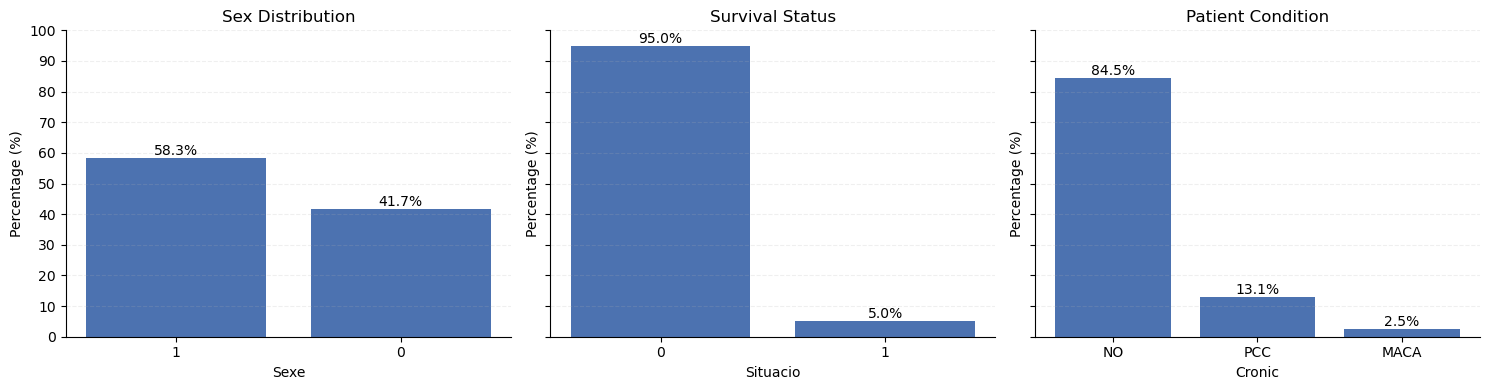

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

plot_percentage_subplot(axes[0], df_usuaris, "sexe", "Sex Distribution")
plot_percentage_subplot(axes[1], df_usuaris, "situacio", "Survival Status")
plot_percentage_subplot(axes[2], df_usuaris, "cronic", "Patient Condition", nan_label="non-chronic")

plt.tight_layout()
plt.show()

## 8. Final Dataset Summary

At this stage, the patient-level dataset has been cleaned, anonymized, and enriched with demographic, clinical, and temporal variables.  
The resulting patient-level dataset serves as the input for all subsequent modeling and analysis notebooks.

In [47]:
# Reset index after ropping rows
df_usuaris = df_usuaris.reset_index(drop=True)
df_usuaris.drop(columns=['cronic'])
df_usuaris = df_usuaris.rename(columns={
    'grup_edat_90>' : 'grup_edat_major_90'
})

print('Final dataset:')
display(df_usuaris.head())
print(f'Number of users: {df_usuaris.shape[0]}')
df_usuaris.to_csv('data/df_usuaris.csv', index=False)

Final dataset:


,id_cip_actual,sexe,situacio,cronic,gma_plng,gma_pniv,grup_edat_75-80,grup_edat_80-85,grup_edat_85-90,grup_edat_major_90,MACA,PCC
0,2,0,0,NO,0.021,2.0,1,0,0,0,0,0
1,3,1,0,NO,NaN,NaN,1,0,0,0,0,0
2,5,1,0,NO,NaN,NaN,1,0,0,0,0,0
3,7,0,0,NO,0.021,2.0,1,0,0,0,0,0
4,8,0,1,NO,NaN,NaN,1,0,0,0,0,0


Number of users: 55979


In [48]:
# Reset index after ropping rows
cip_relations = cip_relations.reset_index(drop=True)
print(f'Final table variables: {cip_relations.columns.to_list()}')
print(f'Number of users: {cip_relations.shape[0]}')
cip_relations.to_csv('data/cip_relations.csv', index=False)

Final table variables: ['cip_anterior', 'cip_anterior_14', 'cip_actual', 'id_cip_anterior', 'id_cip_actual', 'end_window', 'start_window']
Number of users: 63741
